## What is Cook’s Distance?

Cook’s Distance measures how much a single observation influences the entire regression model.

It combines:

- residual size

- leverage

- model complexity

### PART 1 — Basic Cook’s Distance Plot (Statsmodels)

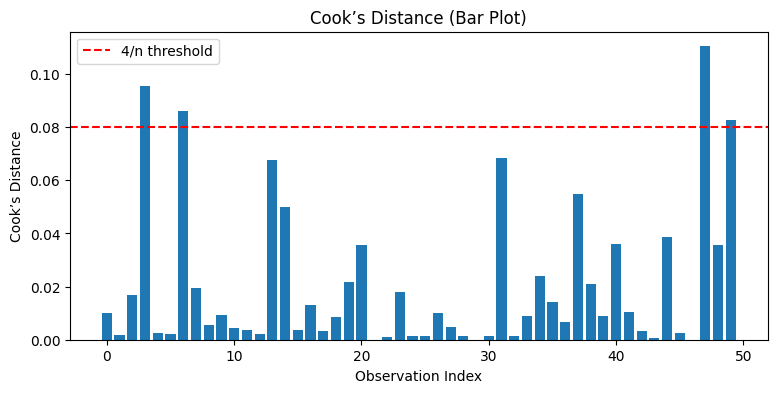

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.linspace(0, 10, 50)
y = 3 * x + np.random.normal(0, 3, 50)

df = pd.DataFrame({"X": x, "Y": y})

# Fit regression
X = sm.add_constant(df["X"])
model = sm.OLS(df["Y"], X).fit()

# Cook's distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(9, 4))
plt.bar(range(len(cooks_d)), cooks_d)

plt.axhline(4 / len(df), color="red", linestyle="--", label="4/n threshold")

plt.xlabel("Observation Index")
plt.ylabel("Cook’s Distance")
plt.title("Cook’s Distance (Bar Plot)")
plt.legend()
plt.show()


### PART 2 — Cleaner Bar-Style Cook’s Distance Plot

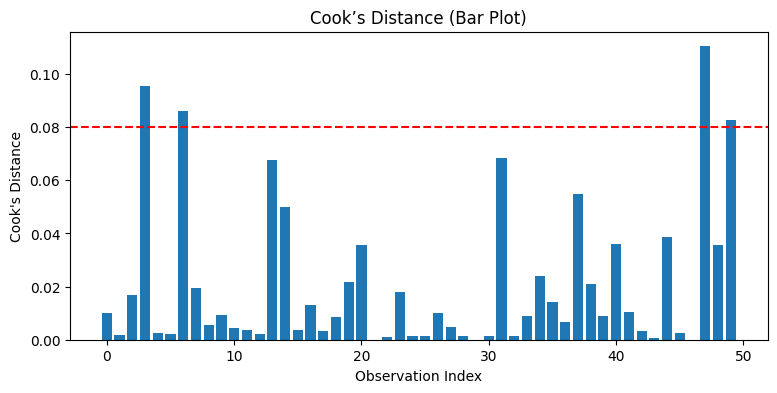

In [2]:
plt.figure(figsize=(9, 4))
plt.bar(range(len(cooks_d)), cooks_d)
plt.axhline(4 / len(df), color="red", linestyle="--")

plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook’s Distance (Bar Plot)")
plt.show()


### PART 3 — Highlight Influential Points Automatically

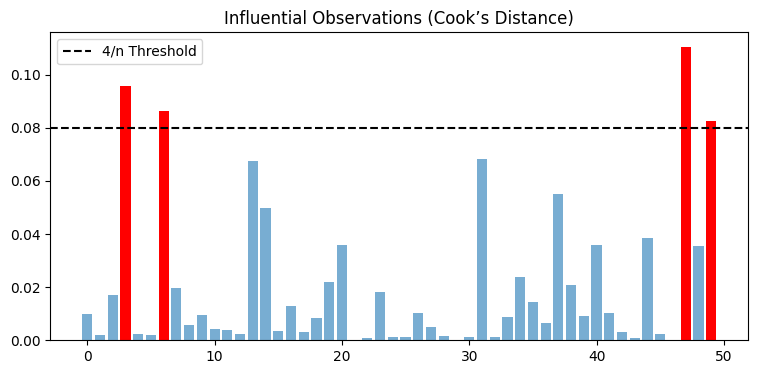

Influential indices: [ 3  6 47 49]


In [3]:
threshold = 4 / len(df)
influential = np.where(cooks_d > threshold)[0]

plt.figure(figsize=(9, 4))
plt.bar(range(len(cooks_d)), cooks_d, alpha=0.6)
plt.bar(influential, cooks_d[influential], color="red")

plt.axhline(threshold, color="black", linestyle="--", label="4/n Threshold")
plt.legend()
plt.title("Influential Observations (Cook’s Distance)")
plt.show()

print("Influential indices:", influential)


### PART 4 — Cook’s Distance with Labels

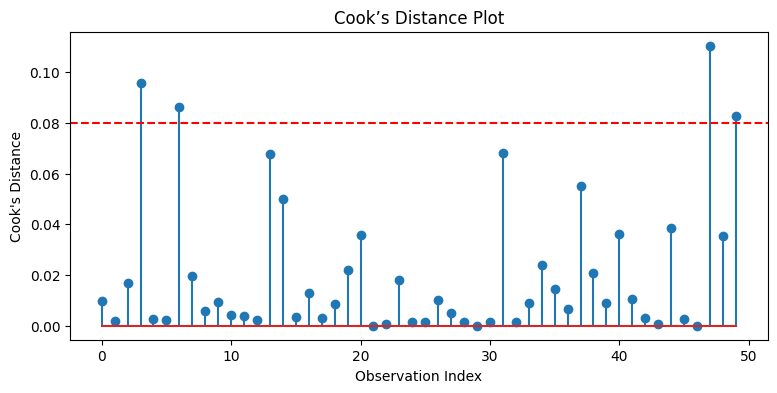

In [12]:
plt.figure(figsize=(9, 4))
plt.stem(cooks_d)

plt.axhline(4 / len(cooks_d), color="red", linestyle="--")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook’s Distance Plot")
plt.show()


### PART 5 — Cook’s Distance vs Leverage (Combined View)

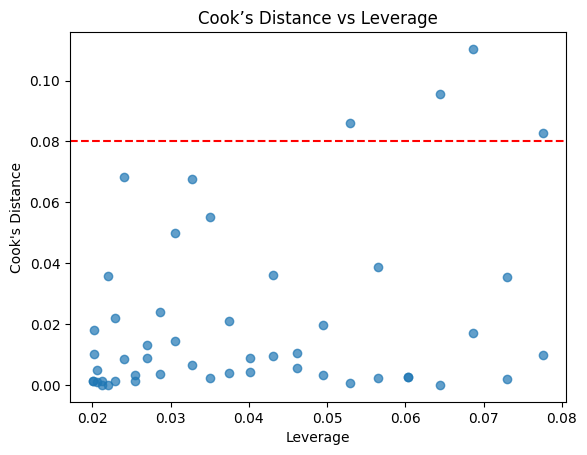

In [6]:
leverage = influence.hat_matrix_diag

plt.scatter(leverage, cooks_d, alpha=0.7)
plt.axhline(4 / len(df), color="red", linestyle="--")

plt.xlabel("Leverage")
plt.ylabel("Cook's Distance")
plt.title("Cook’s Distance vs Leverage")
plt.show()


### PART 6 — Cook’s Distance in Multiple Regression

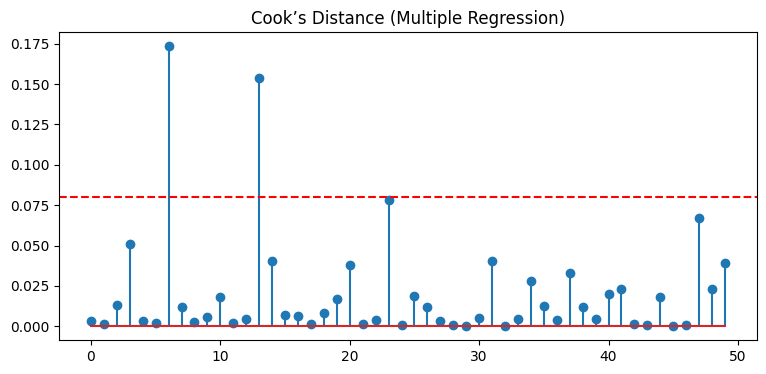

In [13]:
df["X2"] = np.random.normal(0, 1, len(df))
df["X3"] = np.random.normal(2, 1, len(df))

X_multi = sm.add_constant(df[["X", "X2", "X3"]])
model_multi = sm.OLS(df["Y"], X_multi).fit()

infl = model_multi.get_influence()
cooks_multi = infl.cooks_distance[0]

plt.figure(figsize=(9, 4))
plt.stem(cooks_multi)
plt.axhline(4 / len(df), color="red", linestyle="--")
plt.title("Cook’s Distance (Multiple Regression)")
plt.show()


### PART 7 — Tabular Cook’s Distance Summary

In [8]:
summary = pd.DataFrame({
    "CookDistance": cooks_d,
    "Leverage": leverage,
    "StudentizedResidual": influence.resid_studentized_external
})

summary.sort_values("CookDistance", ascending=False).head()


,CookDistance,Leverage,StudentizedResidual
47,0.110388,0.068619,1.769060
3,0.095526,0.064394,1.698496
6,0.086214,0.052869,1.797955
49,0.082647,0.077647,-1.415836
31,0.068215,0.024058,2.474974


### PART 8 — Combine Cook’s Distance with Influence Plot

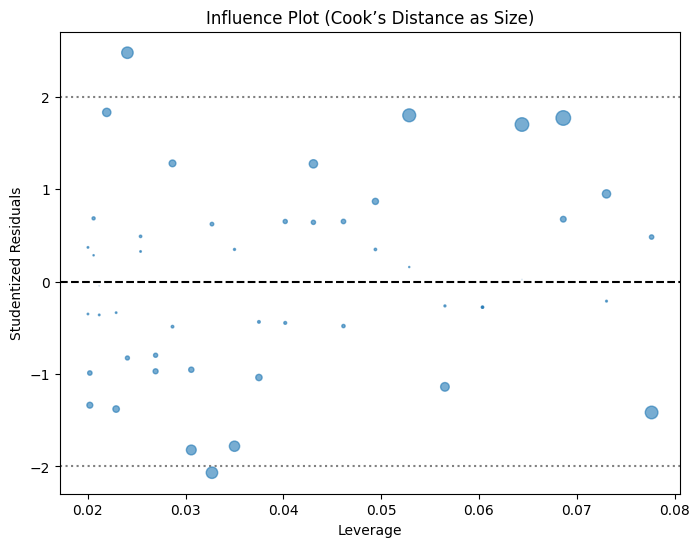

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    leverage,
    influence.resid_studentized_external,
    s=1000 * cooks_d,
    alpha=0.6
)

ax.axhline(0, color="black", linestyle="--")
ax.axhline(2, color="gray", linestyle=":")
ax.axhline(-2, color="gray", linestyle=":")

ax.set_xlabel("Leverage")
ax.set_ylabel("Studentized Residuals")
ax.set_title("Influence Plot (Cook’s Distance as Size)")

plt.show()


### PART 9 — Reusable Function (Clean & Practical)

In [10]:
def cooks_distance_plot(X, y):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    infl = model.get_influence()
    cooks = infl.cooks_distance[0]

    plt.figure(figsize=(9, 4))
    plt.stem(cooks, use_line_collection=True)
    plt.axhline(4 / len(cooks), color="red", linestyle="--")

    plt.xlabel("Observation Index")
    plt.ylabel("Cook's Distance")
    plt.title("Cook’s Distance Plot")
    plt.show()

    return cooks
